# **QUESTION 1: LOGISTIC REGRESSION**

---

## **1. Derivation of the Sigmoid Function**

Given that,

$$
p = P(y = 1 \mid x) = \sigma(z)
$$

Let us assume that the log-odds is a linear function of $x$:

$$
\log\left(\frac{p}{1 - p}\right) = w^T x + b
$$

Exponentiating both sides:

$$
\frac{p}{1 - p} = e^{w^T x + b}
$$

Solving for $p$:

$$
p = (1 - p)e^{w^T x + b} \tag{1}
$$

$$
p + pe^{w^T x + b} = e^{w^T x + b} \tag{2}
$$

$$
p(1 + e^{w^T x + b}) = e^{w^T x + b} \tag{3}
$$

$$
p = \frac{e^{w^T x + b}}{1 + e^{w^T x + b}} \tag{4}
$$

Dividing the numerator and denominator by $e^{w^T x + b}$:

$$
p = \frac{1}{1 + e^{-(w^T x + b)}}
$$

Let $z = w^T x + b$.  
The sigmoid activation function is:

$$
\boxed{
\sigma(z) = \frac{1}{1 + e^{-z}}
}
$$

---

## **2. Derivation of Negative Log Loss**

The probability for a single observation is given by:

$$
P(y \mid x) = \hat{y}^{\,y}(1 - \hat{y})^{(1 - y)}
$$

For a dataset of $m$ independent observations, the likelihood function is:

$$
\mathcal{L} =
\prod_{i=1}^{m}
\hat{y}_i^{\,y_i}(1 - \hat{y}_i)^{(1 - y_i)}
$$

Taking the logarithm:

$$
\ln \mathcal{L} =
\sum_{i=1}^{m}
\left[
y_i \ln(\hat{y}_i) + (1 - y_i)\ln(1 - \hat{y}_i)
\right]
$$

Maximum Likelihood Estimation maximizes the log-likelihood.  
Equivalently, we minimize the negative log-likelihood:

$$
\boxed{
\mathcal{L}_{\text{NLL}} =
- \sum_{i=1}^{m}
\left[
y_i \ln(\hat{y}_i) + (1 - y_i)\ln(1 - \hat{y}_i)
\right]
}
$$

---

## **3. Why Mean Squared Error with Sigmoid Is Problematic**

Using Mean Squared Error (MSE):

$$
L = \frac{1}{2}(\hat{y} - y)^2,
\quad \text{where } \hat{y} = \sigma(z)
$$

The derivative of the sigmoid function is:

$$
\frac{\partial \sigma(z)}{\partial z}
= \sigma(z)(1 - \sigma(z))
= \hat{y}(1 - \hat{y})
$$

The gradient of the loss with respect to $z$ is:

$$
\frac{\partial L}{\partial z}
= (\hat{y} - y)\frac{\partial \sigma(z)}{\partial z}
$$

$$
\frac{\partial L}{\partial z}
= (\hat{y} - y)\hat{y}(1 - \hat{y})
$$

When $z \to -\infty$, $\hat{y} \to 0$, therefore:

$$
(\hat{y} - y)\hat{y}(1 - \hat{y}) \approx 0
$$

Similarly, when $z \to \infty$, $\hat{y} \to 1$, therefore:

$$
(\hat{y} - y)\hat{y}(1 - \hat{y}) \approx 0
$$

Even for large values of $z$, the gradient $\frac{\partial L}{\partial z}$ is close to zero.  
This leads to **vanishing gradients** and **slow convergence**.

In [36]:
# QUESTION  2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve
from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv("/content/creditcard.csv")

# data summary
data.head()
data.info()
data.describe()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [37]:
# checking for null values
data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [38]:
# droping null rows
data = data.dropna()
data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [39]:
# print class imbalance
data["Class"].value_counts()
data["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


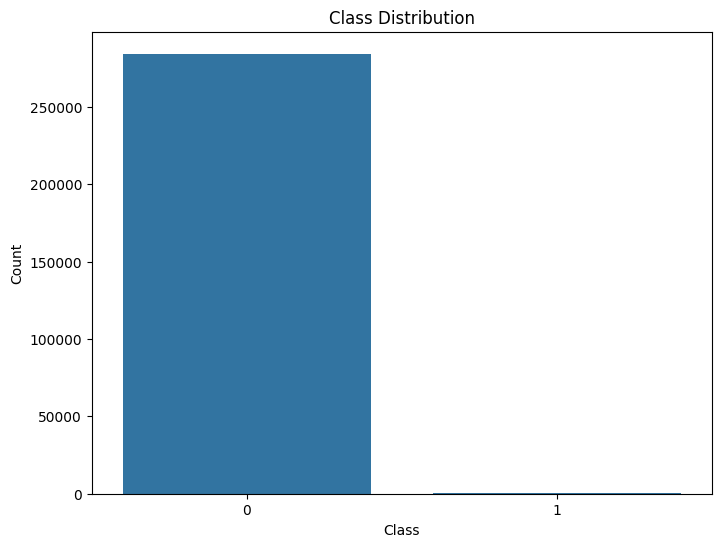

In [40]:
# class imbalance ploting
plt.figure(figsize=(8, 6))
sns.countplot(x="Class", data=data)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [41]:
X = data.drop("Class", axis=1)
y = data["Class"]

# scale the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=== Standard Logistic Regression ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# print confussion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Use sklearn weighted model probabilities
y_prob_std = lr.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_std)




=== Standard Logistic Regression ===
Accuracy : 0.9991
Precision: 0.8636
Recall   : 0.5816
F1 Score : 0.6951
Confusion Matrix:
[[56855     9]
 [   41    57]]


Class weights: {0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}

=== Weighted Logistic Regression ===
Accuracy : 0.9764
Precision: 0.0630
Recall   : 0.9184
F1 Score : 0.1179
Confusion Matrix:
[[55525  1339]
 [    8    90]]


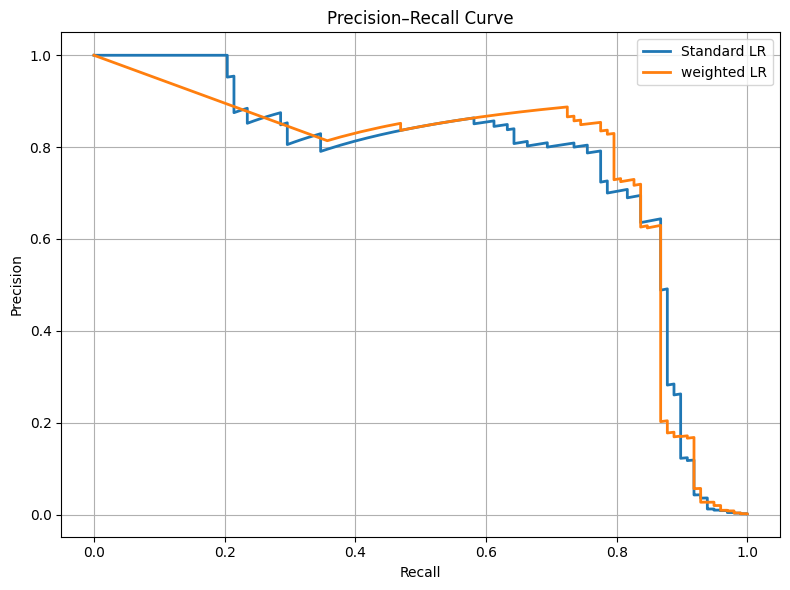

In [42]:
# weighted model
# Compute class weights proportional to inverse frequency
n_total = len(y_train)
n_fraud = np.sum(y_train == 1)
n_normal = np.sum(y_train == 0)

w_fraud = n_total / (2 * n_fraud)
w_normal = n_total / (2 * n_normal)

class_weights = {0: w_normal, 1: w_fraud}
print("Class weights:", class_weights)

# Train weighted logistic regression
lr_weighted = LogisticRegression(max_iter=1000, class_weight=class_weights, random_state=42)
lr_weighted.fit(X_train, y_train)

# Predictions
y_pred_w = lr_weighted.predict(X_test)

# Metrics
accuracy_w  = accuracy_score(y_test, y_pred_w)
precision_w = precision_score(y_test, y_pred_w)
recall_w    = recall_score(y_test, y_pred_w)
f1_w        = f1_score(y_test, y_pred_w)

print("\n=== Weighted Logistic Regression ===")
print(f"Accuracy : {accuracy_w:.4f}")
print(f"Precision: {precision_w:.4f}")
print(f"Recall   : {recall_w:.4f}")
print(f"F1 Score : {f1_w:.4f}")

# print confussion matrix
cm = confusion_matrix(y_test, y_pred_w)
print("Confusion Matrix:")
print(cm)

# Use sklearn weighted model probabilities
y_prob_w = lr_weighted.predict_proba(X_test)[:, 1]
precision_w, recall_w, thresholds_w = precision_recall_curve(y_test, y_prob_w)

# Plot PR curve

plt.figure(figsize=(8, 6))

# Weighted Logistic Regression
plt.plot(
    recall, precision,
    label='Standard LR',
    linewidth=2
)

# Standard Logistic Regression
plt.plot(
    recall_w, precision_w,
    label='weighted LR',
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [43]:
target_recall = 0.80

idx = np.where(recall >= target_recall)[0][-1]
threshold_80 = thresholds[idx]
precision_80 = precision[idx]
recall_80 = recall[idx]

print("\n=== Threshold Selection ===")
print(f"Threshold for ≥80% recall: {threshold_80:.4f}")
print(f"Recall   : {recall_80:.4f}")
print(f"Precision: {precision_80:.4f}")




=== Threshold Selection ===
Threshold for ≥80% recall: 0.0435
Recall   : 0.8061
Precision: 0.7054


## Summarize Weighted Loss Function Derivative


### Explanation of Weighted Loss Function

A **weighted loss function** in logistic regression modifies the standard negative log-likelihood loss by assigning different penalties to misclassifications of different classes. For a binary classification problem with classes 0 (majority) and 1 (minority), the standard log-likelihood is:

$$L = - \sum_{i=1}^{m} [y_i \ln(\hat{y}_i) + (1 - y_i)\ln(1 - \hat{y}_i)]$$

In a weighted loss function, we introduce class-specific weights, typically denoted as $w_0$ for the majority class and $w_1$ for the minority class:

$$L_{\text{weighted}} = - \sum_{i=1}^{m} [w_{y_i} \cdot y_i \ln(\hat{y}_i) + w_{1-y_i} \cdot (1 - y_i)\ln(1 - \hat{y}_i)]$$

Where $w_{y_i}$ is the weight corresponding to the true class of instance $i$. For instance, if $y_i=1$, the term becomes $w_1 \ln(\hat{y}_i)$. If $y_i=0$, the term becomes $w_0 \ln(1 - \hat{y}_i)$.

### Purpose in Handling Class Imbalance

Class weighting is crucial for **handling class imbalance**, a common problem where one class (the majority) significantly outnumbers the other (the minority). In such scenarios, a standard logistic regression model tends to be biased towards the majority class because minimizing the overall error naturally leads to better prediction of the more frequent class. This results in high accuracy but poor performance (low recall/precision) on the minority class, which is often the class of interest (e.g., fraud detection, disease diagnosis).

By assigning a **higher weight to the minority class** ($w_1 > w_0$), the model is penalized more heavily for misclassifying a minority instance than for misclassifying a majority instance. This forces the model to pay more attention to the minority class, effectively making its errors more 'costly' during training. Consequently, the model learns to better distinguish and predict the minority class, improving metrics like recall and F1-score for the rare class.

### Effect on Derivative Calculation

The derivative of the loss function guides the optimization process by indicating the direction and magnitude of parameter updates. For the standard logistic regression loss, the derivative with respect to the pre-activation input $z$ for a single instance is:

$$\frac{\partial L}{\partial z} = (\hat{y} - y)$$

When using a weighted loss function, the derivative for a single instance changes. If an instance belongs to the minority class ($y=1$), its contribution to the gradient will be scaled by its assigned weight $w_1$. Similarly, if it belongs to the majority class ($y=0$), its contribution will be scaled by $w_0$. Intuitively, the derivative will look something like:

$$\frac{\partial L_{\text{weighted}}}{\partial z} = w_{y} (\hat{y} - y)$$

Where $w_y$ is the weight corresponding to the true label $y$. If $y=1$, this term becomes $w_1(\hat{y}-1)$. If $y=0$, it becomes $w_0(\hat{y}-0)$.

By having $w_1 > w_0$, the gradients originating from minority class instances will have a larger magnitude. This means that when the model makes an error on a minority class instance, the parameters will be adjusted more significantly than if it made an error on a majority class instance. This amplifies the learning signal from the under-represented class, pushing the model to reduce errors on this class more aggressively during training and ultimately leading to a better-balanced model.

## Explain Accuracy Trap

### The Accuracy Trap

The **Accuracy Trap** refers to the phenomenon where a model appears to perform well based solely on its overall accuracy, but this high accuracy is misleading, particularly when dealing with **highly imbalanced datasets**. An imbalanced dataset is one where the number of observations in one class is significantly lower than the number of observations in other classes.

#### Why Accuracy is Misleading in Imbalanced Datasets:

Consider a credit card fraud detection dataset, like the one used in the previous steps, where only 0.17% of transactions are fraudulent (Class = 1) and the vast majority (99.83%) are legitimate (Class = 0). If a model simply predicts every transaction as non-fraudulent (Class = 0), it would achieve an accuracy of 99.83%. While this accuracy seems very high, the model is completely useless because it fails to detect any fraudulent transactions, which is the primary goal.

In such scenarios, accuracy is misleading because:
*   **It doesn't differentiate between types of errors:** A model might have high accuracy by correctly classifying the majority class, but completely fail at identifying the minority class, which is often the class of most interest (e.g., fraud, disease, rare events).
*   **It masks poor performance on the minority class:** A small number of misclassifications of the minority class can have a negligible impact on overall accuracy, even if those misclassifications are critical.

#### Why Precision, Recall, and F1-Score are More Informative:

When dealing with imbalanced datasets, it's crucial to use metrics that focus on the performance of the model on the minority class. **Precision**, **Recall**, and **F1-score** are such metrics:

1.  **Precision (Positive Predictive Value):**
    *   **What it measures:** Out of all instances predicted as positive, how many were actually positive?
    *   **Formula:** `Precision = True Positives / (True Positives + False Positives)`
    *   **Relevance:** High precision indicates a low rate of false alarms. In fraud detection, high precision means that when the model predicts fraud, it is usually correct, minimizing wasted resources investigating legitimate transactions.

2.  **Recall (Sensitivity or True Positive Rate):**
    *   **What it measures:** Out of all actual positive instances, how many were correctly predicted as positive?
    *   **Formula:** `Recall = True Positives / (True Positives + False Negatives)`
    *   **Relevance:** High recall indicates that the model is good at finding all positive instances. In fraud detection, high recall means the model catches most of the fraudulent transactions, minimizing financial losses due to undetected fraud.

3.  **F1-Score:**
    *   **What it measures:** The harmonic mean of precision and recall. It provides a single metric that balances both precision and recall.
    *   **Formula:** `F1-Score = 2 * (Precision * Recall) / (Precision + Recall)`
    *   **Relevance:** The F1-score is particularly useful when you need to find an optimal balance between precision and recall, especially when both false positives and false negatives have significant costs. A high F1-score indicates that the model has good performance with respect to both identifying positive instances and not raising too many false alarms.

In our fraud detection example, a model that simply predicts non-fraudulent will have a recall of 0 (it catches no fraud) and an F1-score of 0, despite its high accuracy. This clearly highlights its inadequacy, unlike accuracy alone.

### Comparison of Standard vs. Weighted Logistic Regression

This section compares the performance of the standard Logistic Regression model with the Weighted Logistic Regression model, focusing on their confusion matrices and key evaluation metrics.

#### Standard Logistic Regression Model

**Confusion Matrix:**
```
[[56855     9]
 [   41    57]]
```

*   **True Negatives (TN):** 56855 (Correctly identified non-fraudulent transactions)
*   **False Positives (FP):** 9 (Non-fraudulent transactions incorrectly identified as fraudulent)
*   **False Negatives (FN):** 41 (Fraudulent transactions incorrectly identified as non-fraudulent)
*   **True Positives (TP):** 57 (Correctly identified fraudulent transactions)

**Metrics:**
*   **Accuracy :** 0.9991
*   **Precision:** 0.8636
*   **Recall   :** 0.5816
*   **F1 Score :** 0.6951

#### Weighted Logistic Regression Model

**Confusion Matrix:**
```
[[55525  1339]
 [    8    90]]
```

*   **True Negatives (TN):** 55525 (Correctly identified non-fraudulent transactions)
*   **False Positives (FP):** 1339 (Non-fraudulent transactions incorrectly identified as fraudulent)
*   **False Negatives (FN):** 8 (Fraudulent transactions incorrectly identified as non-fraudulent)
*   **True Positives (TP):** 90 (Correctly identified fraudulent transactions)

**Metrics:**
*   **Accuracy :** 0.9764
*   **Precision:** 0.0630
*   **Recall   :** 0.9184
*   **F1 Score :** 0.1179

#### Comparative Analysis and Impact of Class Weighting

The comparison between the standard and weighted logistic regression models clearly illustrates the effectiveness of class weighting in addressing imbalanced datasets, albeit with trade-offs.

1.  **True Positives (TP):** The most significant improvement is seen in True Positives. The **standard model** identified 57 fraudulent transactions, whereas the **weighted model** identified 90. This represents a substantial increase in the detection of the minority class, which is often the primary goal in imbalanced scenarios like fraud detection.

2.  **False Negatives (FN):** Correspondingly, the number of False Negatives decreased dramatically. The **standard model** missed 41 fraudulent transactions, while the **weighted model** only missed 8. Reducing false negatives is critical in applications where missing positive instances (e.g., fraud, disease) can have severe consequences.

3.  **False Positives (FP):** The improvement in TP and reduction in FN came at the cost of an increased number of False Positives. The **standard model** had only 9 false positives, but the **weighted model** had 1339. This means the weighted model flagged many more legitimate transactions as fraudulent, leading to more

### Comparison of Standard vs. Weighted Logistic Regression

This section compares the performance of the standard Logistic Regression model with the Weighted Logistic Regression model, focusing on their confusion matrices and key evaluation metrics.

#### Standard Logistic Regression Model

**Confusion Matrix:**
```
[[56855     9]
 [   41    57]]
```

*   **True Negatives (TN):** 56855 (Correctly identified non-fraudulent transactions)
*   **False Positives (FP):** 9 (Non-fraudulent transactions incorrectly identified as fraudulent)
*   **False Negatives (FN):** 41 (Fraudulent transactions incorrectly identified as non-fraudulent)
*   **True Positives (TP):** 57 (Correctly identified fraudulent transactions)

**Metrics:**
*   **Accuracy :** 0.9991
*   **Precision:** 0.8636
*   **Recall   :** 0.5816
*   **F1 Score :** 0.6951

#### Weighted Logistic Regression Model

**Confusion Matrix:**
```
[[55525  1339]
 [    8    90]]
```

*   **True Negatives (TN):** 55525 (Correctly identified non-fraudulent transactions)
*   **False Positives (FP):** 1339 (Non-fraudulent transactions incorrectly identified as fraudulent)
*   **False Negatives (FN):** 8 (Fraudulent transactions incorrectly identified as non-fraudulent)
*   **True Positives (TP):** 90 (Correctly identified fraudulent transactions)

**Metrics:**
*   **Accuracy :** 0.9764
*   **Precision:** 0.0630
*   **Recall   :** 0.9184
*   **F1 Score :** 0.1179

#### Comparative Analysis and Impact of Class Weighting

The comparison between the standard and weighted logistic regression models clearly illustrates the effectiveness of class weighting in addressing imbalanced datasets, albeit with trade-offs.

1.  **True Positives (TP):** The most significant improvement is seen in True Positives. The **standard model** identified 57 fraudulent transactions, whereas the **weighted model** identified 90. This represents a substantial increase in the detection of the minority class, which is often the primary goal in imbalanced scenarios like fraud detection.

2.  **False Negatives (FN):** Correspondingly, the number of False Negatives decreased dramatically. The **standard model** missed 41 fraudulent transactions, while the **weighted model** only missed 8. Reducing false negatives is critical in applications where missing positive instances (e.g., fraud, disease) can have severe consequences.

3.  **False Positives (FP):** The improvement in TP and reduction in FN came at the cost of an increased number of False Positives. The **standard model** had only 9 false positives, but the **weighted model** had 1339. This means the weighted model flagged many more legitimate transactions as fraudulent, leading to more

## Summary:

### Data Analysis Key Findings

*   **Weighted Loss Function in Logistic Regression**:
    *   A weighted loss function modifies the standard negative log-likelihood by assigning class-specific weights, typically a higher weight to the minority class ($w_1$) and a lower weight to the majority class ($w_0$).
    *   Its purpose is to address class imbalance by penalizing misclassifications of the minority class more heavily, forcing the model to learn to better distinguish and predict the minority class.
    *   The derivative of the weighted loss function amplifies the gradients from minority class instances by scaling them with $w_1$, leading to more significant parameter adjustments when errors occur on these instances, thereby boosting the learning signal from the under-represented class.
*   **The 'Accuracy Trap'**:
    *   The 'Accuracy Trap' refers to high overall accuracy being misleading, especially in highly imbalanced datasets, because a model can achieve high accuracy by simply predicting the majority class, completely failing to detect the minority class.
    *   For example, in a fraud detection dataset where 99.83% of transactions are legitimate, a model predicting all transactions as non-fraudulent would achieve 99.83% accuracy but miss all fraudulent cases.
    *   Metrics like Precision, Recall, and F1-score are more informative for imbalanced datasets:
        *   **Precision** measures the proportion of correctly predicted positive instances out of all instances predicted as positive.
        *   **Recall** measures the proportion of correctly predicted positive instances out of all actual positive instances.
        *   **F1-Score** provides a balanced measure of both precision and recall.
*   **Comparison of Standard vs. Weighted Logistic Regression Models**:
    *   **True Positives (TP)**: The weighted model significantly increased TP, identifying 90 fraudulent transactions compared to 57 by the standard model.
    *   **False Negatives (FN)**: The weighted model dramatically reduced FN, missing only 8 fraudulent transactions, whereas the standard model missed 41. This shows a much better detection rate for the minority class.
    *   **False Positives (FP)**: The improvement in TP and reduction in FN came at a significant cost of increased FP. The weighted model had 1339 false positives, a substantial rise from the standard model's 9. This means many legitimate transactions were incorrectly flagged as fraudulent.
    *   **True Negatives (TN)**: Consequently, the True Negatives decreased from 56855 (standard) to 55525 (weighted) due to the increased false positives.
    *   **Overall Metrics**:
        *   The standard model showed high accuracy (0.9991) and precision (0.8636) but moderate recall (0.5816).
        *   The weighted model prioritized recall (0.9184) at the expense of accuracy (0.9764) and significantly lower precision (0.0630). This highlights the typical trade-off when optimizing for minority class detection in imbalanced datasets.

